# Fake News Detection Using DistilBERT and Deep Learning

## Introduction

Fake news and misinformation have become serious challenges in the digital world, where misleading information can spread rapidly through online news platforms, blogs, and social media. Traditional machine learning models can classify text using word-frequency techniques such as TF-IDF, but they may struggle to understand the deeper meaning and context of language.

This project develops an advanced fake news detection system using **DistilBERT**, a transformer-based deep learning model. DistilBERT is a smaller and faster version of BERT that can understand contextual relationships between words in a sentence. This makes it more suitable for natural language processing tasks such as text classification.

The dataset is loaded directly inside the Google Colab runtime using **KaggleHub**, so there is no need to manually upload files or download the dataset to a local computer. The dataset contains two files: `Fake.csv` and `True.csv`. Each article is labelled as either fake news or true news.

In this project, the title and article body are combined to create a complete text input. The text is lightly cleaned while preserving sentence structure, because transformer models perform better when natural language context is retained. The data is then tokenized using the DistilBERT tokenizer and converted into a format suitable for deep learning training.

The DistilBERT model is fine-tuned for binary text classification. After training, the model is evaluated using accuracy, precision, recall, F1-score, confusion matrix, ROC-AUC score, and ROC curve. The system also includes a confidence score and an **Uncertain / Needs Verification** category for predictions where the model is not confident enough.

An attention-based explanation section is included to show which tokens the model focuses on during prediction. Finally, the notebook provides a manual testing feature where users can paste their own news article and receive a prediction.

## Objectives

- Load the fake and real news dataset directly inside Google Colab.
- Build a deep learning fake news classifier using DistilBERT.
- Combine article titles and body text for better context.
- Tokenize text using the DistilBERT tokenizer.
- Fine-tune a transformer model for binary news classification.
- Evaluate the model using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, and ROC curve.
- Add prediction confidence scores.
- Include an Uncertain / Needs Verification category for low-confidence predictions.
- Provide an attention-based explanation for model predictions.
- Allow users to manually test custom news articles.

In [1]:
# 1. Install Required Packages

!pip -q install kagglehub transformers datasets accelerate evaluate

In [2]:
# 2. Import Libraries

import os
import re
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

In [3]:
# 3. Configuration

RANDOM_STATE = 42

MODEL_NAME = "distilbert-base-uncased"

ID2LABEL = {
    0: "Fake News",
    1: "True News"
}

LABEL2ID = {
    "Fake News": 0,
    "True News": 1
}

CONFIDENCE_THRESHOLD = 0.70

# Set True for better results but slower training.
USE_FULL_DATASET = False

# Used only when USE_FULL_DATASET = False
SAMPLE_SIZE = 12000

# For CPU, use smaller settings.
# For GPU, you can increase MAX_LENGTH to 512 and EPOCHS to 3.
MAX_LENGTH = 256
EPOCHS = 2

TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

In [4]:
# 4. Check Device

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Warning: GPU is not enabled.")
    print("This code can run on CPU, but training will be slow.")
    print("Recommended: Runtime → Change runtime type → GPU")

Device: cuda
GPU: Tesla T4


In [5]:
# 5. Load Dataset Directly Inside Colab Runtime

print("\nFetching dataset inside Colab runtime...")

dataset_path = kagglehub.dataset_download(
    "clmentbisaillon/fake-and-real-news-dataset"
)

print("\nDataset path inside Colab runtime:")
print(dataset_path)

print("\nFiles found:")
print(os.listdir(dataset_path))


Fetching dataset inside Colab runtime...
Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.

Dataset path inside Colab runtime:
/kaggle/input/fake-and-real-news-dataset

Files found:
['True.csv', 'Fake.csv']


In [6]:
# 6. Read Fake.csv and True.csv

fake_path = os.path.join(dataset_path, "Fake.csv")
true_path = os.path.join(dataset_path, "True.csv")

data_fake = pd.read_csv(fake_path)
data_true = pd.read_csv(true_path)

print("\nFake dataset shape:", data_fake.shape)
print("True dataset shape:", data_true.shape)

print("\nFake columns:", data_fake.columns.tolist())
print("True columns:", data_true.columns.tolist())


Fake dataset shape: (23481, 4)
True dataset shape: (21417, 4)

Fake columns: ['title', 'text', 'subject', 'date']
True columns: ['title', 'text', 'subject', 'date']


In [7]:
# 7. Add Labels

# 0 = Fake News
# 1 = True News

data_fake["label"] = 0
data_true["label"] = 1

In [8]:
# 8. Combine Title + Text

data_fake["content"] = (
    data_fake["title"].astype(str) + " " + data_fake["text"].astype(str)
)

data_true["content"] = (
    data_true["title"].astype(str) + " " + data_true["text"].astype(str)
)

data_fake = data_fake[["content", "label"]]
data_true = data_true[["content", "label"]]

In [9]:
# 9. Merge and Shuffle Dataset

data = pd.concat([data_fake, data_true], axis=0)
data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nMerged dataset shape:", data.shape)

print("\nClass distribution:")
print(data["label"].value_counts())

print("\nClass meaning:")
print("0 = Fake News")
print("1 = True News")


Merged dataset shape: (44898, 2)

Class distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Class meaning:
0 = Fake News
1 = True News


In [10]:
# 10. Light Text Cleaning for Transformer

# Do not over-clean text for BERT-style models.
# Keep sentence structure and context.

def clean_text_for_transformer(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


print("\nCleaning text...")
data["content"] = data["content"].apply(clean_text_for_transformer)
print("Cleaning completed.")


Cleaning text...
Cleaning completed.


In [11]:
# 11. Optional Balanced Sampling

if not USE_FULL_DATASET:
    print(f"\nUsing a balanced sample of {SAMPLE_SIZE} rows for faster training...")

    fake_count = SAMPLE_SIZE // 2
    true_count = SAMPLE_SIZE // 2

    fake_sample = data[data["label"] == 0].sample(
        n=fake_count,
        random_state=RANDOM_STATE
    )

    true_sample = data[data["label"] == 1].sample(
        n=true_count,
        random_state=RANDOM_STATE
    )

    data = pd.concat([fake_sample, true_sample], axis=0)
    data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nFinal dataset shape used:", data.shape)

print("\nFinal class distribution:")
print(data["label"].value_counts())


Using a balanced sample of 12000 rows for faster training...

Final dataset shape used: (12000, 2)

Final class distribution:
label
0    6000
1    6000
Name: count, dtype: int64


In [12]:
# 12. Train / Validation / Test Split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    data["content"],
    data["label"],
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=data["label"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_labels
)

train_df = pd.DataFrame({
    "text": train_texts,
    "label": train_labels
})

val_df = pd.DataFrame({
    "text": val_texts,
    "label": val_labels
})

test_df = pd.DataFrame({
    "text": test_texts,
    "label": test_labels
})

print("\nTrain size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)


Train size: (8400, 2)
Validation size: (1800, 2)
Test size: (1800, 2)


In [13]:
# 13. Convert Pandas DataFrames to Hugging Face Datasets

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

In [14]:
# 14. Load Tokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [15]:
# 15. Tokenize Datasets

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )


print("\nTokenizing datasets...")

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenization completed.")


Tokenizing datasets...


Map:   0%|          | 0/8400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

Tokenization completed.


In [16]:
# 16. Load DistilBERT Model

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

model.to(device)

print("\nModel loaded successfully.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded successfully.


In [17]:
# 17. Metrics Function

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [18]:
# 18. Training Arguments

# Handles different transformers versions where argument names may differ.

def create_training_arguments():
    try:
        args = TrainingArguments(
            output_dir="./distilbert_fake_news_results",
            eval_strategy="epoch",
            save_strategy="epoch",
            learning_rate=LEARNING_RATE,
            per_device_train_batch_size=TRAIN_BATCH_SIZE,
            per_device_eval_batch_size=EVAL_BATCH_SIZE,
            num_train_epochs=EPOCHS,
            weight_decay=WEIGHT_DECAY,
            load_best_model_at_end=True,
            metric_for_best_model="f1",
            greater_is_better=True,
            logging_steps=50,
            save_total_limit=1,
            report_to="none",
            seed=RANDOM_STATE
        )
    except TypeError:
        args = TrainingArguments(
            output_dir="./distilbert_fake_news_results",
            evaluation_strategy="epoch",
            save_strategy="epoch",
            learning_rate=LEARNING_RATE,
            per_device_train_batch_size=TRAIN_BATCH_SIZE,
            per_device_eval_batch_size=EVAL_BATCH_SIZE,
            num_train_epochs=EPOCHS,
            weight_decay=WEIGHT_DECAY,
            load_best_model_at_end=True,
            metric_for_best_model="f1",
            greater_is_better=True,
            logging_steps=50,
            save_total_limit=1,
            report_to="none",
            seed=RANDOM_STATE
        )

    return args


training_args = create_training_arguments()

In [19]:
# 19. Create Trainer

trainer_kwargs = {
    "model": model,
    "args": training_args,
    "train_dataset": train_dataset,
    "eval_dataset": val_dataset,
    "data_collator": data_collator,
    "compute_metrics": compute_metrics,
    "callbacks": [
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
}

try:
    trainer = Trainer(
        **trainer_kwargs,
        processing_class=tokenizer
    )
except TypeError:
    try:
        trainer = Trainer(
            **trainer_kwargs,
            tokenizer=tokenizer
        )
    except TypeError:
        trainer = Trainer(
            **trainer_kwargs
        )

print("\nTrainer created successfully.")


Trainer created successfully.


In [20]:
# 20. Train Model

print("\nStarting DistilBERT fine-tuning...")

trainer.train()

print("\nTraining completed.")


Starting DistilBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.001762,0.003066,0.999444,0.998890,1.000000,0.999445
2,0.007708,0.007239,0.998889,0.997783,1.000000,0.998890


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training completed.


In [21]:
# 21. Evaluate on Validation Set

print("\nValidation evaluation:")

validation_results = trainer.evaluate()

print(validation_results)


Validation evaluation:


{'eval_loss': 0.003067391226068139, 'eval_accuracy': 0.9994444444444445, 'eval_precision': 0.9988901220865705, 'eval_recall': 1.0, 'eval_f1': 0.9994447529150472, 'eval_runtime': 12.1268, 'eval_samples_per_second': 148.431, 'eval_steps_per_second': 9.318, 'epoch': 2.0}


In [22]:
# 22. Predict on Test Set

print("\nRunning predictions on test set...")

test_output = trainer.predict(test_dataset)

test_logits = test_output.predictions
test_true_labels = test_output.label_ids

test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=1
).numpy()

test_predictions = np.argmax(test_probabilities, axis=1)

test_fake_probs = test_probabilities[:, 0]
test_true_probs = test_probabilities[:, 1]


Running predictions on test set...


In [23]:
# 23. Final Evaluation

test_accuracy = accuracy_score(test_true_labels, test_predictions)
test_roc_auc = roc_auc_score(test_true_labels, test_true_probs)

print("\n" + "=" * 80)
print("Final Test Evaluation - DistilBERT")
print("=" * 80)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test ROC-AUC: {test_roc_auc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    test_true_labels,
    test_predictions,
    target_names=["Fake News", "True News"]
))


Final Test Evaluation - DistilBERT
Test Accuracy: 99.78%
Test ROC-AUC: 100.00%

Classification Report:
              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00       900
   True News       1.00      1.00      1.00       900

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



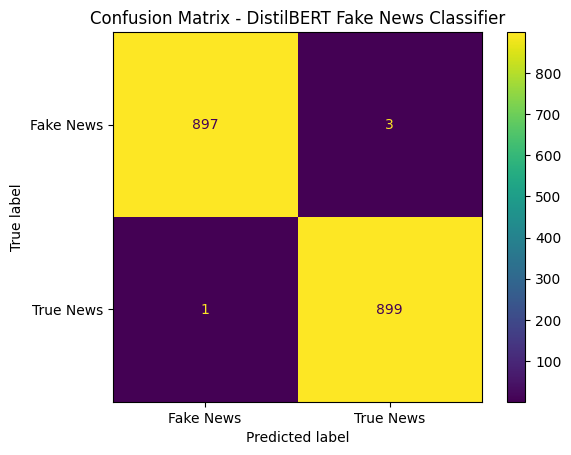

In [24]:
# 24. Confusion Matrix

cm = confusion_matrix(test_true_labels, test_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake News", "True News"]
)

disp.plot()
plt.title("Confusion Matrix - DistilBERT Fake News Classifier")
plt.show()

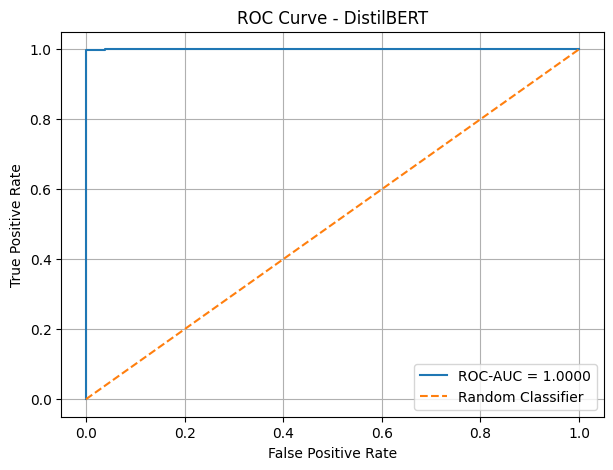

In [25]:
# 25. ROC Curve

fpr, tpr, thresholds = roc_curve(test_true_labels, test_true_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {test_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DistilBERT")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# 26. Deep Learning Prediction Function

def predict_news_deep_learning(news_text, threshold=CONFIDENCE_THRESHOLD):
    cleaned_text = clean_text_for_transformer(news_text)

    inputs = tokenizer(
        cleaned_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]

    fake_probability = float(probabilities[0])
    true_probability = float(probabilities[1])

    predicted_class = int(np.argmax(probabilities))
    confidence = float(np.max(probabilities))

    if confidence < threshold:
        final_label = "Uncertain / Needs Verification"
    else:
        if predicted_class == 0:
            final_label = "Likely Fake News"
        else:
            final_label = "Likely True News"

    print("\n" + "=" * 80)
    print("Deep Learning Prediction Result")
    print("=" * 80)

    print("\nInput News:")
    print(news_text)

    print("\nFinal Prediction:", final_label)
    print(f"Fake Probability: {fake_probability * 100:.2f}%")
    print(f"True Probability: {true_probability * 100:.2f}%")
    print(f"Model Confidence: {confidence * 100:.2f}%")

    if final_label == "Uncertain / Needs Verification":
        print("\nWarning:")
        print("The model is not confident enough. Verify this article manually.")

    print("=" * 80)

    return {
        "final_label": final_label,
        "fake_probability": fake_probability,
        "true_probability": true_probability,
        "confidence": confidence
    }

In [27]:
# 27. Attention-Based Explanation

def explain_with_attention(news_text, top_n=15):
    cleaned_text = clean_text_for_transformer(news_text)

    inputs = tokenizer(
        cleaned_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    attentions = outputs.attentions

    if attentions is None:
        print("\nAttention output is not available.")
        return

    # Last layer attention: batch, heads, tokens, tokens
    last_layer_attention = attentions[-1][0]

    # Average across heads
    avg_attention = last_layer_attention.mean(dim=0)

    # CLS token attention to all tokens
    cls_attention = avg_attention[0].detach().cpu().numpy()

    input_ids = inputs["input_ids"][0].detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    token_scores = list(zip(tokens, cls_attention))

    token_scores = [
        (token, score)
        for token, score in token_scores
        if token not in ["[CLS]", "[SEP]", "[PAD]"]
    ]

    token_scores = sorted(
        token_scores,
        key=lambda x: x[1],
        reverse=True
    )

    print("\n" + "=" * 80)
    print("Attention-Based Explanation")
    print("=" * 80)

    print("\nTokens receiving higher attention:")
    for token, score in token_scores[:top_n]:
        print(f"{token}: {score:.5f}")

    print("\nNote:")
    print("Attention is not a perfect explanation, but it gives a useful")
    print("indication of which tokens the model focused on.")

    print("=" * 80)

In [28]:
# 28. Test Example News

example_true_news = """
NASA scientists announced that the agency has completed a successful space mission
and researchers are now analyzing the collected scientific data.
"""

example_fake_news = """
Breaking news: Scientists confirm that drinking one cup of miracle water can cure
all diseases overnight without any medical treatment.
"""

print("\nTesting example true-style news:")
predict_news_deep_learning(example_true_news)
explain_with_attention(example_true_news)

print("\nTesting example fake-style news:")
predict_news_deep_learning(example_fake_news)
explain_with_attention(example_fake_news)

`sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.



Testing example true-style news:

Deep Learning Prediction Result

Input News:

NASA scientists announced that the agency has completed a successful space mission
and researchers are now analyzing the collected scientific data.


Final Prediction: Likely Fake News
Fake Probability: 99.41%
True Probability: 0.59%
Model Confidence: 99.41%

Attention output is not available.

Testing example fake-style news:

Deep Learning Prediction Result

Input News:

Breaking news: Scientists confirm that drinking one cup of miracle water can cure
all diseases overnight without any medical treatment.


Final Prediction: Likely Fake News
Fake Probability: 99.89%
True Probability: 0.11%
Model Confidence: 99.89%

Attention output is not available.


In [29]:
# 29. Manual Testing

print("\n" + "=" * 80)
print("Manual Testing - Deep Learning Model")
print("=" * 80)

while True:
    choice = input("\nDo you want to test a news article? yes/no: ").strip().lower()

    if choice == "yes":
        user_news = input("\nPaste the news article here:\n")

        predict_news_deep_learning(
            user_news,
            threshold=CONFIDENCE_THRESHOLD
        )

        show_explanation = input("\nShow attention-based explanation? yes/no: ").strip().lower()

        if show_explanation == "yes":
            explain_with_attention(user_news)

    elif choice == "no":
        print("\nTesting completed.")
        break

    else:
        print("Please type yes or no.")


Manual Testing - Deep Learning Model

Do you want to test a news article? yes/no: yes

Paste the news article here:
A viral article shared on several social media pages claims that a group of doctors has discovered a simple home remedy that can cure all forms of cancer within three days. According to the article, the treatment involves drinking a mixture of lemon juice, baking soda, and warm water every morning.  The article says that hospitals and pharmaceutical companies are hiding this discovery from the public because they want to continue making money from expensive treatments. It also claims that people should stop taking prescribed medicine and use the remedy instead.  However, the article does not mention any verified medical study, hospital, research institution, doctor names, clinical trial results, or official health organization statement. It encourages readers to share the information quickly before it is removed from the internet.

Deep Learning Prediction Result

Input 